In [1]:
import numpy as np
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import Average, Input
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load your models
model1 = load_model('MODElS/CNN_LTSM10.h5')
model2 = load_model('MODElS/CNN10.h5')
model3 = load_model('MODElS/CNNbi10.h5')

In [3]:
# Load your test datasets
X_test = np.load('TEST1/X_test.npy')
y_test = np.load('TEST1/y_test.npy')


62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step
Model1 Accuracy: 0.9772612430520465
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       185
           1       0.98      0.99      0.98      1137
           2       0.97      0.96      0.97       627
           3       0.93      0.90      0.92        30

    accuracy                           0.98      1979
   macro avg       0.97      0.96      0.96      1979
weighted avg       0.98      0.98      0.98      1979

Model1 ROC AUC Score: 0.9951994328596666


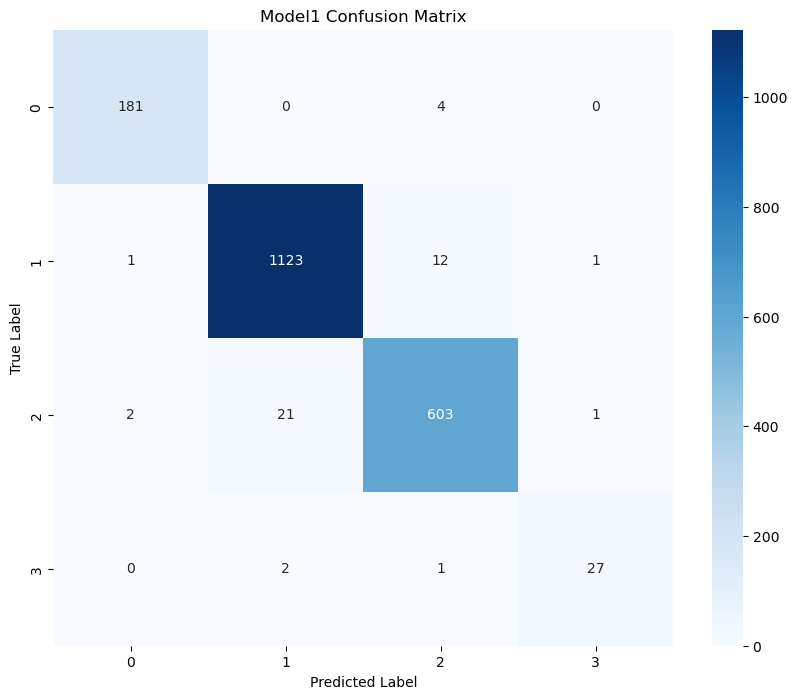

Model1 True Correct Predictions: 1934
Model1 False Predictions: 45
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
Model2 Accuracy: 0.9706922688226377
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       185
           1       0.98      0.99      0.98      1137
           2       0.96      0.95      0.96       627
           3       0.97      0.93      0.95        30

    accuracy                           0.97      1979
   macro avg       0.97      0.95      0.96      1979
weighted avg       0.97      0.97      0.97      1979

Model2 ROC AUC Score: 0.9934917662674315


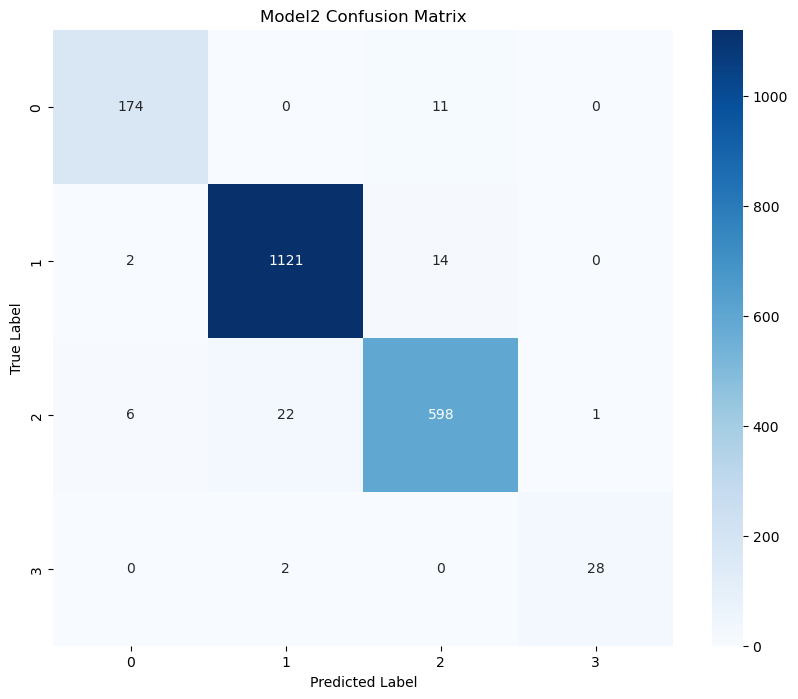

Model2 True Correct Predictions: 1921
Model2 False Predictions: 58
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step
Model3 Accuracy: 0.9747347145022739
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       185
           1       0.97      0.99      0.98      1137
           2       0.97      0.96      0.96       627
           3       1.00      0.90      0.95        30

    accuracy                           0.97      1979
   macro avg       0.98      0.95      0.97      1979
weighted avg       0.97      0.97      0.97      1979

Model3 ROC AUC Score: 0.9941875212457347


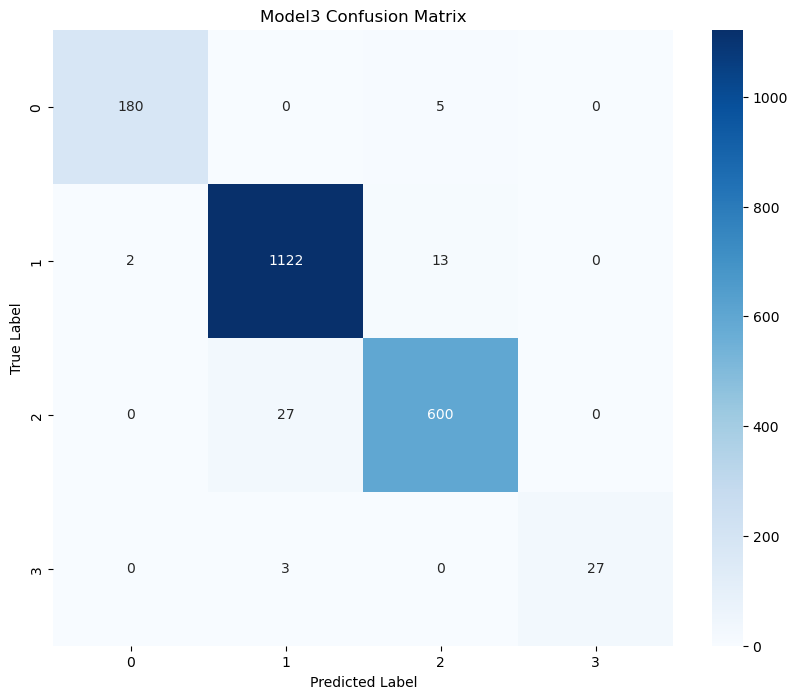

Model3 True Correct Predictions: 1929
Model3 False Predictions: 50


In [4]:
# Define a function to evaluate and plot results for each model
def evaluate_model(model, X_test, y_test, model_name):
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    accuracy = accuracy_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    class_report = classification_report(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_probs, multi_class='ovr')

    print(f"{model_name} Accuracy: {accuracy}")
    print("Classification Report:")
    print(class_report)
    print(f"{model_name} ROC AUC Score: {roc_auc}")

    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()

    true_correct = np.sum(y_test == y_pred)
    false_predictions = np.sum(y_test != y_pred)

    print(f"{model_name} True Correct Predictions: {true_correct}")
    print(f"{model_name} False Predictions: {false_predictions}")

# Evaluate each model individually
evaluate_model(model1, X_test, y_test, "Model1")
evaluate_model(model2, X_test, y_test, "Model2")
evaluate_model(model3, X_test, y_test, "Model3")

In [5]:
# Define a function to extract features from each model
def get_model_predictions(model, X):
    return model.predict(X)

In [7]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Prepare the data for stacking
X_test_meta = np.concatenate([get_model_predictions(model1, X_test),
                               get_model_predictions(model2, X_test),
                               get_model_predictions(model3, X_test)], axis=1)

# Create the base estimators
estimators = [
    ('model1', make_pipeline(StandardScaler(), LogisticRegression())),
    ('model2', make_pipeline(StandardScaler(), LogisticRegression())),
    ('model3', make_pipeline(StandardScaler(), LogisticRegression()))
]

# Create the stacking classifier
stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

# Train the stacking classifier
stacking_clf.fit(X_test_meta, y_test)

62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


StackingClassifier(estimators=[('model1',
                                Pipeline(steps=[('standardscaler',
                                                 StandardScaler()),
                                                ('logisticregression',
                                                 LogisticRegression())])),
                               ('model2',
                                Pipeline(steps=[('standardscaler',
                                                 StandardScaler()),
                                                ('logisticregression',
                                                 LogisticRegression())])),
                               ('model3',
                                Pipeline(steps=[('standardscaler',
                                                 StandardScaler()),
                                                ('logisticregression',
                                                 LogisticRegression())]))],
                   final_estimator=LogisticRegression())

In [8]:
# Make predictions with the stacking classifier
y_pred_stacking = stacking_clf.predict(X_test_meta)

# Evaluate the ensemble model
accuracy_stacking = accuracy_score(y_test, y_pred_stacking)
conf_matrix_stacking = confusion_matrix(y_test, y_pred_stacking)
class_report_stacking = classification_report(y_test, y_pred_stacking)
roc_auc_stacking = roc_auc_score(y_test, stacking_clf.predict_proba(X_test_meta), multi_class='ovr')

print(f"Stacking Ensemble Accuracy: {accuracy_stacking}")
print("Stacking Ensemble Classification Report:")
print(class_report_stacking)
print(f"Stacking Ensemble ROC AUC Score: {roc_auc_stacking}")

Stacking Ensemble Accuracy: 0.9853461344113188
Stacking Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       185
           1       0.98      0.99      0.99      1137
           2       0.99      0.97      0.98       627
           3       1.00      0.93      0.97        30

    accuracy                           0.99      1979
   macro avg       0.99      0.97      0.98      1979
weighted avg       0.99      0.99      0.99      1979

Stacking Ensemble ROC AUC Score: 0.9944690058386736


In [9]:
# Calculate the true and false predictions
true_correct_stacking = np.sum(y_test == y_pred_stacking)
false_predictions_stacking = np.sum(y_test != y_pred_stacking)

print(f"Stacking Ensemble True Correct Predictions: {true_correct_stacking}")
print(f"Stacking Ensemble False Predictions: {false_predictions_stacking}")

Stacking Ensemble True Correct Predictions: 1950
Stacking Ensemble False Predictions: 29


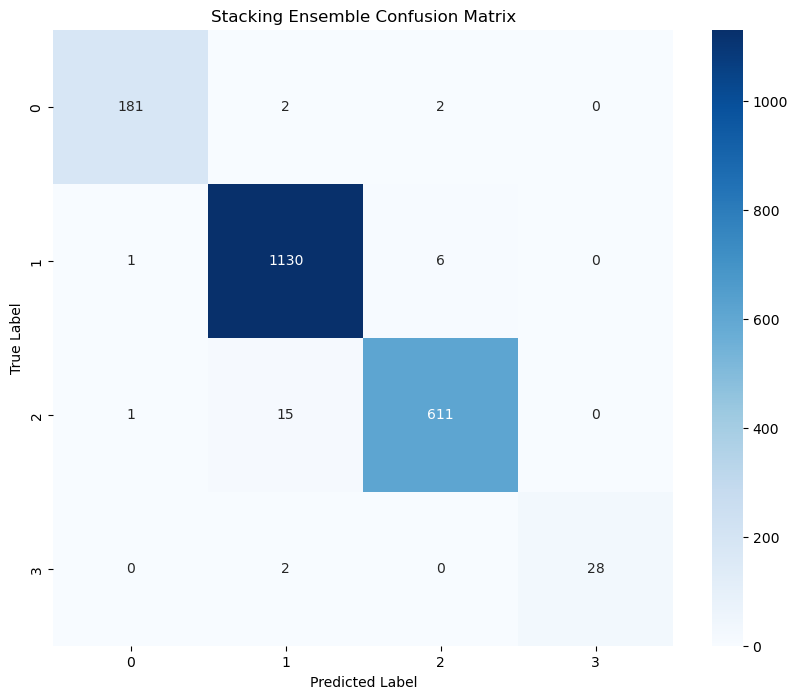

In [10]:
# Plot confusion matrix for stacking ensemble
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_stacking, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Stacking Ensemble Confusion Matrix')
plt.show()

In [11]:
# Compare all models' performance 
model_names = ["Model1", "Model2", "Model3", "Stacking Ensemble"]
accuracies = [accuracy_score(y_test, np.argmax(get_model_predictions(model1, X_test), axis=1)),
              accuracy_score(y_test, np.argmax(get_model_predictions(model2, X_test), axis=1)),
              accuracy_score(y_test, np.argmax(get_model_predictions(model3, X_test), axis=1)),
              accuracy_stacking]


62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


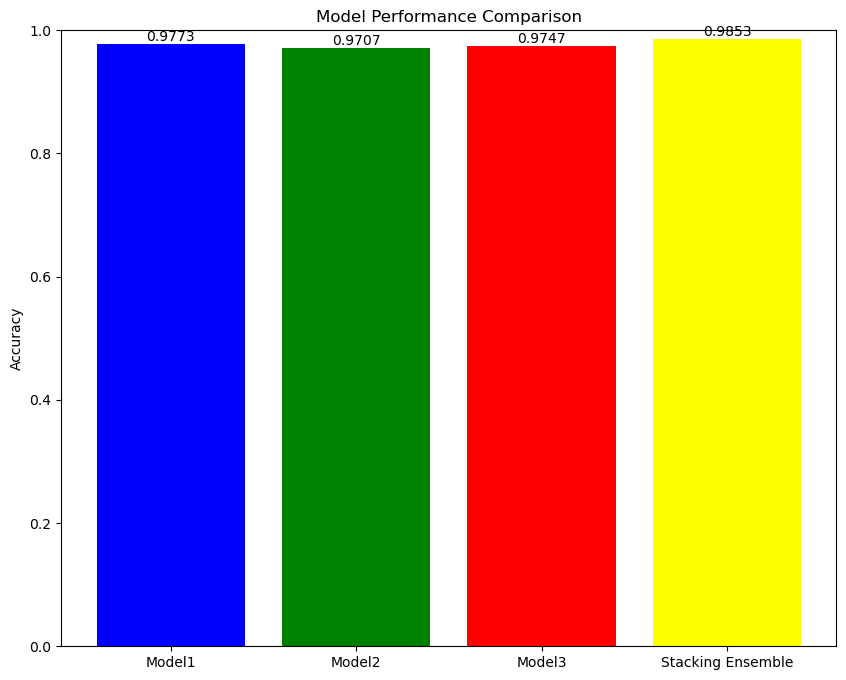

In [12]:
# Define colors for each model
colors = ['blue', 'green', 'red', 'yellow']

plt.figure(figsize=(10, 8))
plt.bar(model_names, accuracies, color=colors)
plt.ylabel('Accuracy')
plt.title('Model Performance Comparison')
plt.ylim(0, 1)
for index, value in enumerate(accuracies):
    plt.text(index, value, f'{value:.4f}', ha='center', va='bottom')
plt.show()

In [13]:
import joblib

# Save the stacking classifier model
stacking_model_path = 'MODElS/stacking_ensemble_model.pkl'
joblib.dump(stacking_clf, stacking_model_path)


['MODElS/stacking_ensemble_model.pkl']

In [14]:
# Save the test set for the ensemble model
np.save('TEST1/X_test_meta_.npy', X_test_meta)